<a href="https://colab.research.google.com/github/Edinson8/mineria-datos-customer-churn/blob/main/Proyecto_Mineria_Datos_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Librerías cargadas correctamente")



Librerías cargadas correctamente


In [1]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()


Filas: 7043
Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
import os

os.makedirs("resultados", exist_ok=True)

print("Carpeta creada correctamente")

Carpeta creada correctamente


In [6]:
import os

print(os.listdir())

['.config', 'resultados', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [7]:
nulos = pd.DataFrame({
    "Variable": df.columns,
    "Nulos": df.isnull().sum(),
    "Porcentaje": (df.isnull().sum()/len(df))*100
})

nulos.to_csv("resultados/tabla_nulos.csv", index=False)

nulos.head()

,Variable,Nulos,Porcentaje
customerID,customerID,0,0.0
gender,gender,0,0.0
SeniorCitizen,SeniorCitizen,0,0.0
Partner,Partner,0,0.0
Dependents,Dependents,0,0.0


In [8]:
duplicados = pd.DataFrame({
    "Cantidad_Duplicados":[df.duplicated().sum()]
})

duplicados.to_csv(
    "resultados/tabla_duplicados.csv",
    index=False
)

duplicados

,Cantidad_Duplicados
0,0


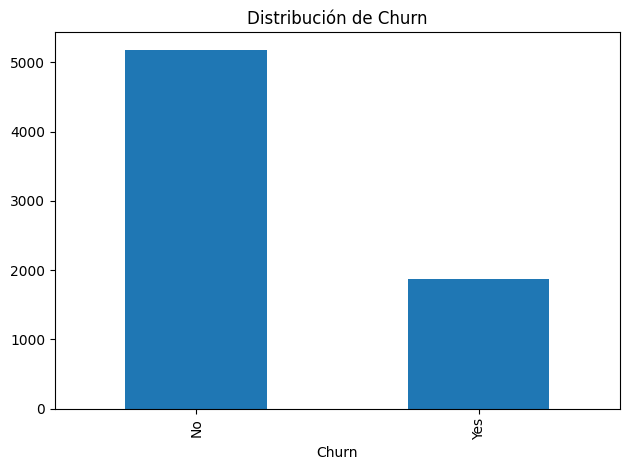

In [9]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Churn")
plt.tight_layout()

plt.savefig(
    "resultados/grafico_churn.png"
)

plt.show()

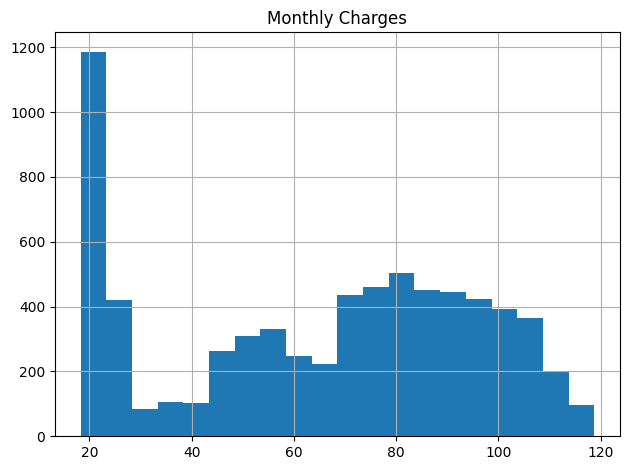

In [10]:
df["MonthlyCharges"].hist(bins=20)

plt.title("Monthly Charges")
plt.tight_layout()

plt.savefig(
    "resultados/histograma_monthlycharges.png"
)

plt.show()